# Global Superstore — Week 3
## Advanced Data Analysis, Statistical Validation & Feature Engineering

**Analyst:** Ozoeze Wilord Ugonna  
**Programme:** AnalystLab Africa Data Science Internship  
**Dataset:** Global Superstore (51,290 orders)

---

### Notebook Objectives
1. Project continuity summary (Weeks 1–2)
2. Advanced Exploratory Data Analysis (new insights)
3. At least 4 statistical hypothesis tests
4. Feature engineering (≥ 3 meaningful features)
5. Feature evaluation & selection
6. Dataset refinement + export modelling dataset
7. Business insights summary


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("Libraries loaded successfully")


Libraries loaded successfully


In [24]:
# Cell 1 should load libraries
# Cell 2 should load:
DATA_PATH = "../data/Global_Superstore2.xlsx"

## 1. Load Week 2 Dataset

We reuse the Global Superstore data prepared in earlier weeks.  
Full re-cleaning from Week 2 is **not** repeated.


In [2]:
# Path relative to notebooks/ folder
DATA_PATH = "../data/Global_Superstore2.xlsx"

df = pd.read_excel(DATA_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape: (51290, 24)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Postal Code', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,2013-05-02 00:00:00,2013-07-02 00:00:00,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,2013-05-11 00:00:00,2013-06-11 00:00:00,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [3]:
# Parse dates
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True, errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True, errors="coerce")

print(df.info())
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  str           
 2   Order Date      51290 non-null  datetime64[us]
 3   Ship Date       51290 non-null  datetime64[us]
 4   Ship Mode       51290 non-null  str           
 5   Customer ID     51290 non-null  str           
 6   Customer Name   51290 non-null  str           
 7   Segment         51290 non-null  str           
 8   City            51290 non-null  str           
 9   State           51290 non-null  str           
 10  Country         51290 non-null  str           
 11  Postal Code     9994 non-null   float64       
 12  Market          51290 non-null  str           
 13  Region          51290 non-null  str           
 14  Product ID      51290 non-null  str           
 15  Category     

## 2. Project Continuity Summary

### Business Problem
Global Superstore needs to understand which products, customer segments, regions, shipping choices, and discount practices **drive or destroy profit**.

### Target of Interest
- Primary: `Profit`
- Derived: Profit Margin, Is_Loss_Making

### Key findings carried from Weeks 1–2
- ~51,290 orders across multiple markets
- Overall margin around 11–12%
- Technology tends to be most profitable; Furniture shows higher loss rates
- Discounting is associated with weaker profit
- Postal Code is largely missing for non-US rows (documented limitation)

### Open questions for Week 3
1. Are profit differences across Categories statistically significant?
2. Do discounted orders produce significantly lower profit?
3. Is Segment associated with Order Priority?
4. How strong are relationships between Sales, Discount, Shipping Cost and Profit?
5. Which engineered features add value for Week 4 modelling?


## 3. Advanced Exploratory Data Analysis

### 3.1 Numerical Analysis
Focus: distributions, skewness, variability, and unusual patterns — deeper than Week 1 overview charts.


In [4]:
num_cols = ["Sales", "Quantity", "Discount", "Profit", "Shipping Cost"]

display(df[num_cols].describe().round(2))
print("\nSkewness:")
print(df[num_cols].skew().round(2))


,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00,51290.00,51290.00,51290.00,51290.00
mean,246.49,3.48,0.14,28.61,26.38
std,487.57,2.28,0.21,174.34,57.30
min,0.44,1.00,0.00,-6599.98,0.00
25%,30.76,2.00,0.00,0.00,2.61
50%,85.05,3.00,0.00,9.24,7.79
75%,251.05,5.00,0.20,36.81,24.45
max,22638.48,14.00,0.85,8399.98,933.57



Skewness:
Sales            8.14
Quantity         1.36
Discount         1.39
Profit           4.16
Shipping Cost    5.86
dtype: float64


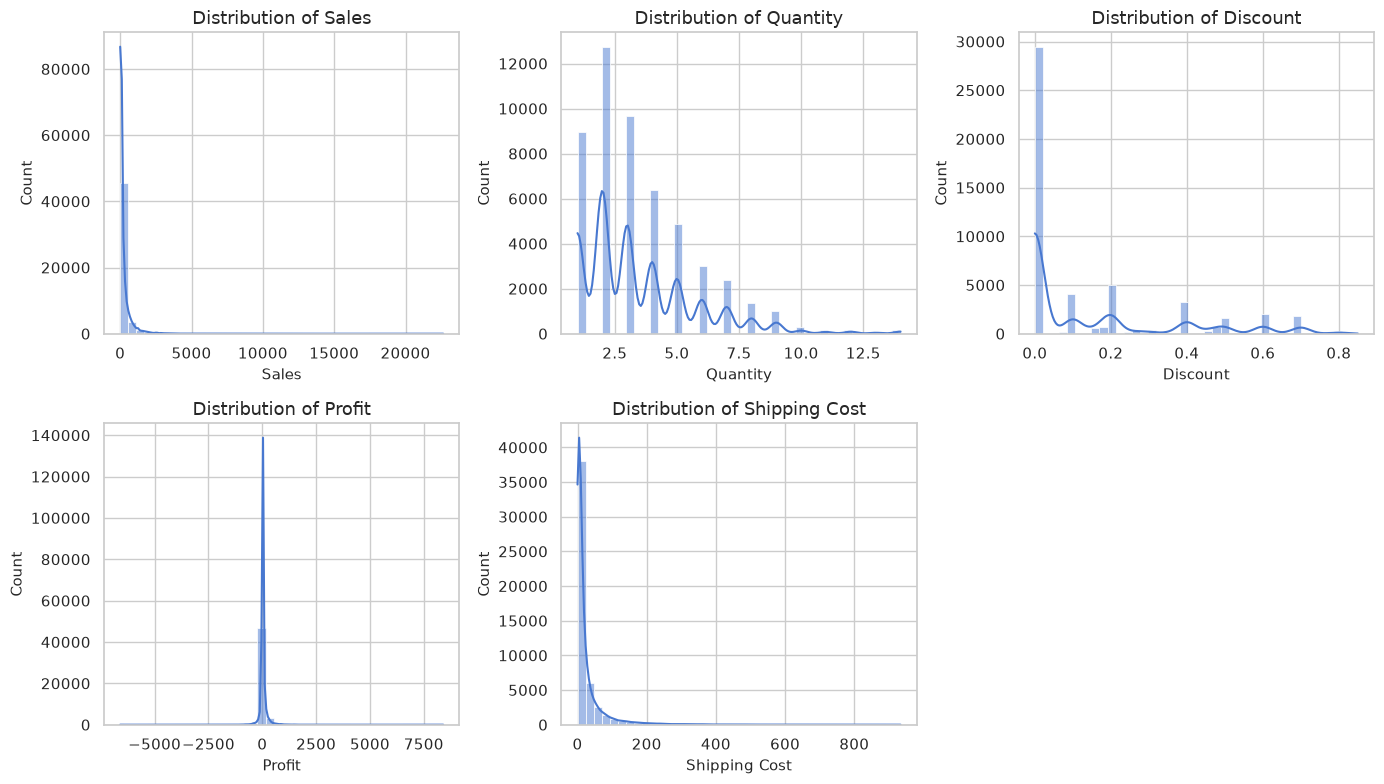

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=40)
    axes[i].set_title(f"Distribution of {col}")
axes[-1].axis("off")
plt.tight_layout()
plt.show()


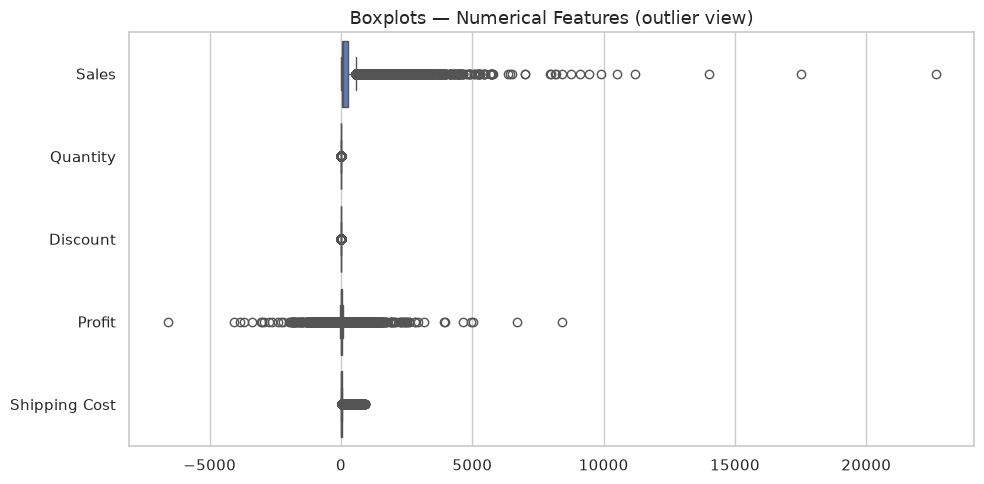

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df[num_cols], orient="h", ax=ax)
ax.set_title("Boxplots — Numerical Features (outlier view)")
plt.tight_layout()
plt.show()


### 3.2 Categorical Analysis

In [7]:
cat_cols = ["Category", "Segment", "Ship Mode", "Order Priority", "Market"]

for col in cat_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")



=== Category ===
Category
Office Supplies    61.0%
Technology         19.8%
Furniture          19.3%
Name: proportion, dtype: str

=== Segment ===
Segment
Consumer       51.7%
Corporate      30.1%
Home Office    18.2%
Name: proportion, dtype: str

=== Ship Mode ===
Ship Mode
Standard Class    60.0%
Second Class      20.1%
First Class       14.6%
Same Day           5.3%
Name: proportion, dtype: str

=== Order Priority ===
Order Priority
Medium      57.4%
High        30.2%
Critical     7.7%
Low          4.7%
Name: proportion, dtype: str

=== Market ===
Market
APAC      21.5%
LATAM     20.1%
EU        19.5%
US        19.5%
EMEA       9.8%
Africa     8.9%
Canada     0.7%
Name: proportion, dtype: str


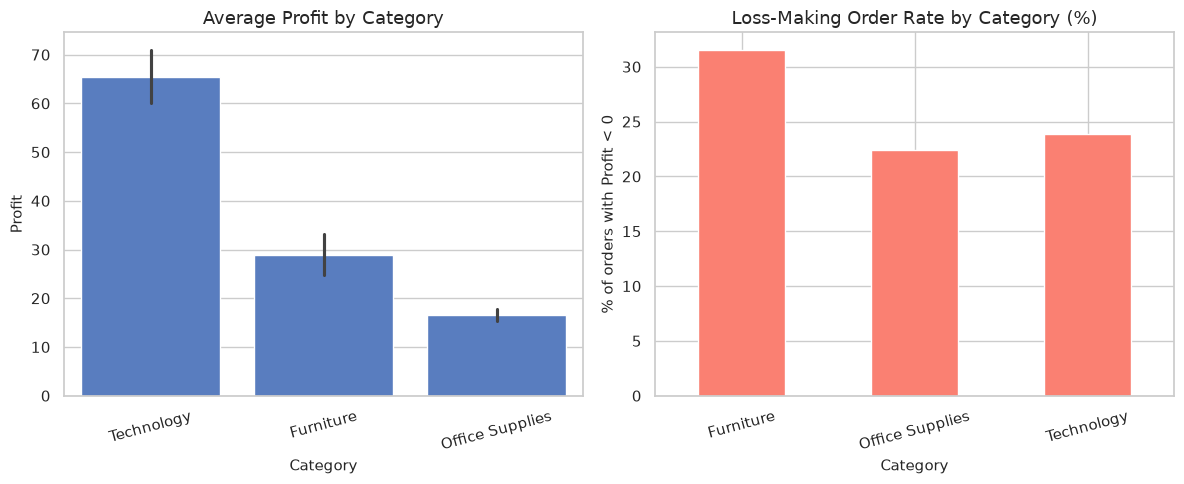

Loss rate by Category (%):
Category
Furniture          31.6
Office Supplies    22.4
Technology         23.9
Name: loss, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=df, x="Category", y="Profit", estimator=np.mean, ci=95, ax=axes[0])
axes[0].set_title("Average Profit by Category")
axes[0].tick_params(axis="x", rotation=15)

loss_rate = df.assign(loss=(df["Profit"] < 0)).groupby("Category")["loss"].mean().mul(100)
loss_rate.plot(kind="bar", ax=axes[1], color="salmon")
axes[1].set_title("Loss-Making Order Rate by Category (%)")
axes[1].set_ylabel("% of orders with Profit < 0")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

print("Loss rate by Category (%):")
print(loss_rate.round(1))


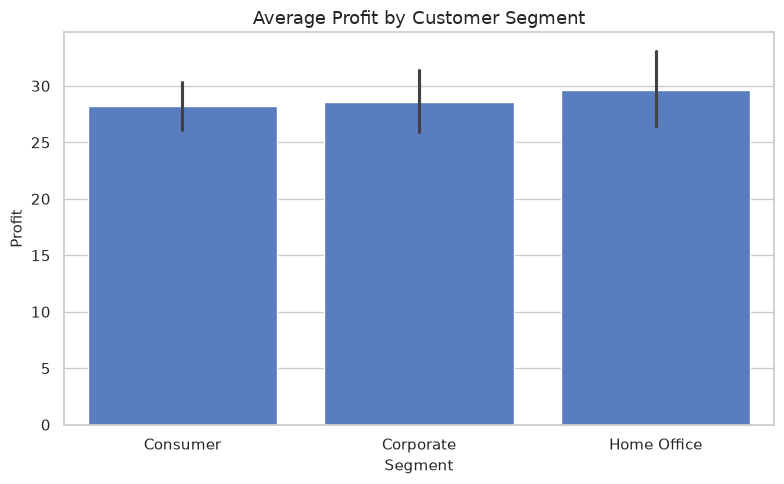

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df, x="Segment", y="Profit", estimator=np.mean, ci=95, ax=ax)
ax.set_title("Average Profit by Customer Segment")
plt.tight_layout()
plt.show()


### 3.3 Bivariate & Multivariate Analysis

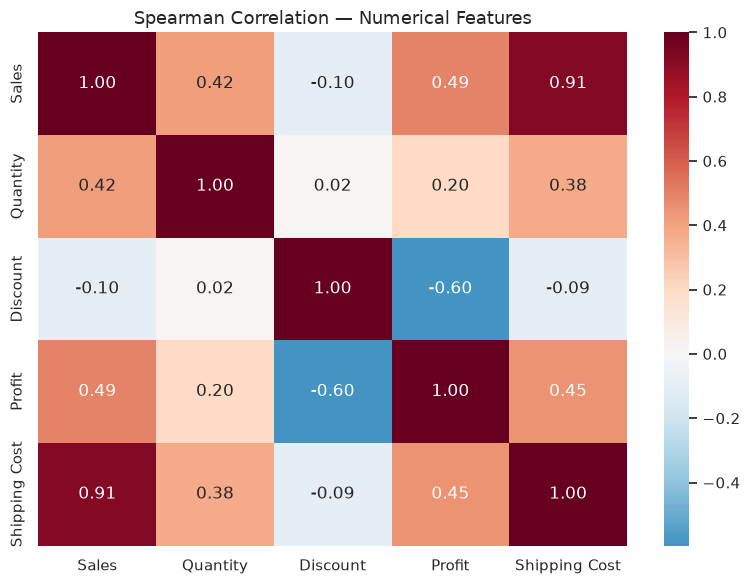

In [10]:
corr = df[num_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, fmt=".2f", ax=ax)
ax.set_title("Spearman Correlation — Numerical Features")
plt.tight_layout()
plt.show()


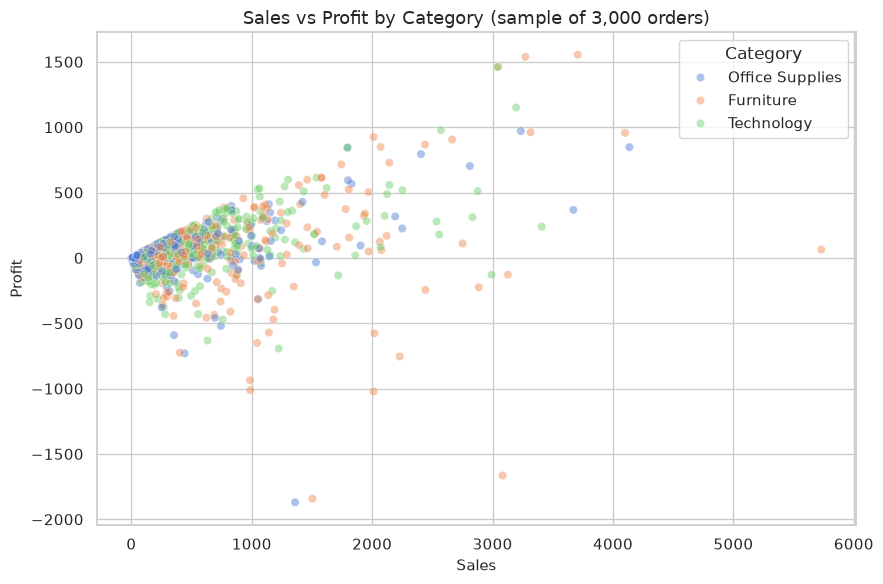

In [11]:
sample = df.sample(min(3000, len(df)), random_state=42)
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=sample, x="Sales", y="Profit", hue="Category", alpha=0.45, ax=ax)
ax.set_title("Sales vs Profit by Category (sample of 3,000 orders)")
plt.tight_layout()
plt.show()


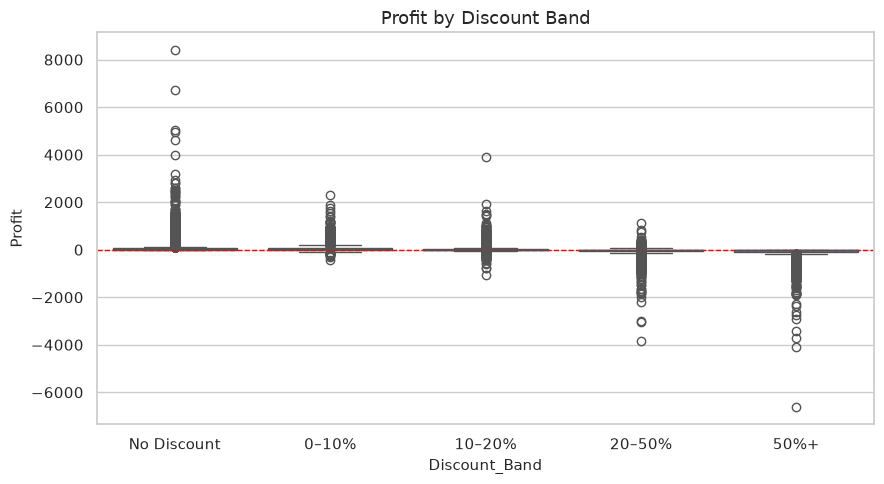

                mean  median  count
Discount_Band                      
No Discount    61.04   17.82  29009
0–10%          72.28   22.01   4679
10–20%         27.61    6.55   6274
20–50%        -56.19  -15.43   7156
50%+          -98.89  -25.22   4172


In [12]:
df["Discount_Band"] = pd.cut(
    df["Discount"],
    bins=[-0.01, 0, 0.1, 0.2, 0.5, 1],
    labels=["No Discount", "0–10%", "10–20%", "20–50%", "50%+"]
)
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="Discount_Band", y="Profit", ax=ax)
ax.set_title("Profit by Discount Band")
ax.axhline(0, color="red", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

print(df.groupby("Discount_Band")["Profit"].agg(["mean", "median", "count"]).round(2))


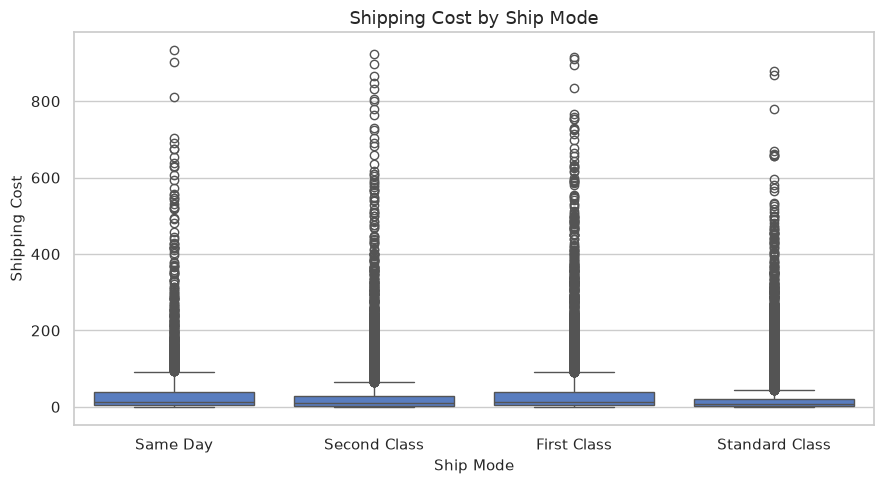

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="Ship Mode", y="Shipping Cost", ax=ax)
ax.set_title("Shipping Cost by Ship Mode")
plt.tight_layout()
plt.show()


## 4. Statistical Hypothesis Testing

At least four tests are performed. For each test we document:
- Business question
- H₀ / H₁
- Method & justification
- Result
- Decision
- Business implication


### Test 1 — Profit across Categories (Kruskal-Wallis)

**Business question:** Is average profit significantly different across Furniture, Office Supplies, and Technology?

**H₀:** Mean / distribution of Profit is the same across categories.  
**H₁:** At least one category differs.

**Method:** Kruskal-Wallis H-test (non-parametric). Profit is skewed with outliers, so ANOVA assumptions are weak.


In [14]:
groups = [g["Profit"].dropna().values for _, g in df.groupby("Category")]
stat, p = stats.kruskal(*groups)
print("Test 1 — Kruskal-Wallis (Profit ~ Category)")
print(f"  H statistic = {stat:.4f}")
print(f"  p-value     = {p:.4e}")
print("  Decision    :", "Reject H0" if p < 0.05 else "Fail to reject H0")
print("\nMean Profit by Category:")
print(df.groupby("Category")["Profit"].mean().round(2))


Test 1 — Kruskal-Wallis (Profit ~ Category)
  H statistic = 1793.8645
  p-value     = 0.0000e+00
  Decision    : Reject H0

Mean Profit by Category:
Category
Furniture          28.88
Office Supplies    16.58
Technology         65.45
Name: Profit, dtype: float64


**Interpretation:** If p < 0.05, category is a statistically significant driver of profit.  
**Business implication:** Technology should be prioritised for growth; Furniture needs margin protection.


### Test 2 — Discounted vs Non-Discounted Profit (Mann-Whitney U)

**Business question:** Do discounted orders generate significantly lower profit than non-discounted orders?

**H₀:** Profit distributions are equal.  
**H₁:** Profit distributions differ.

**Method:** Mann-Whitney U (two independent samples, non-normal).


In [15]:
no_disc = df.loc[df["Discount"] == 0, "Profit"].dropna()
with_disc = df.loc[df["Discount"] > 0, "Profit"].dropna()
stat, p = stats.mannwhitneyu(no_disc, with_disc, alternative="two-sided")
print("Test 2 — Mann-Whitney U (Profit: No Discount vs Discount)")
print(f"  U statistic = {stat:.4f}")
print(f"  p-value     = {p:.4e}")
print(f"  Mean No Discount  = {no_disc.mean():.2f}")
print(f"  Mean With Discount = {with_disc.mean():.2f}")
print(f"  % orders discounted = {(df['Discount'] > 0).mean()*100:.1f}%")
print("  Decision    :", "Reject H0" if p < 0.05 else "Fail to reject H0")


Test 2 — Mann-Whitney U (Profit: No Discount vs Discount)
  U statistic = 504526621.0000
  p-value     = 0.0000e+00
  Mean No Discount  = 61.04
  Mean With Discount = -13.61
  % orders discounted = 43.4%
  Decision    : Reject H0


**Business implication:** Current discounting is strongly associated with weaker (often negative) profit. Discount policy needs redesign.


### Test 3 — Segment vs Order Priority (Chi-Square)

**Business question:** Is there an association between customer Segment and Order Priority?

**H₀:** Segment and Order Priority are independent.  
**H₁:** They are associated.

**Method:** Chi-Square Test of Independence.


In [16]:
ct = pd.crosstab(df["Segment"], df["Order Priority"])
chi2, p, dof, exp = stats.chi2_contingency(ct)
print("Test 3 — Chi-Square (Segment vs Order Priority)")
print("Contingency table:")
display(ct)
print(f"  Chi2 = {chi2:.4f}, dof = {dof}, p-value = {p:.4e}")
print("  Decision:", "Reject H0" if p < 0.05 else "Fail to reject H0")


Test 3 — Chi-Square (Segment vs Order Priority)
Contingency table:


Order Priority,Critical,High,Low,Medium
Segment,,,,
Consumer,2071,8257,1173,15017
Corporate,1185,4431,744,9069
Home Office,676,2813,507,5347


  Chi2 = 44.9504, dof = 6, p-value = 4.7875e-08
  Decision: Reject H0


**Business implication:** If associated, service priority may be uneven across segments. Align service levels with segment strategy and value.


### Test 4 — Spearman Correlations with Profit

**Business question:** How strongly are Sales, Discount, Shipping Cost, and Quantity related to Profit?

**Method:** Spearman rank correlation (robust to skewness/outliers).


In [17]:
print("Test 4 — Spearman Correlations with Profit")
print("-" * 50)
for col in ["Sales", "Discount", "Shipping Cost", "Quantity"]:
    r, p = stats.spearmanr(df[col], df["Profit"], nan_policy="omit")
    sig = "significant" if p < 0.05 else "not significant"
    print(f"  {col:15s}  rho = {r:7.4f}  p = {p:.4e}  ({sig})")


Test 4 — Spearman Correlations with Profit
--------------------------------------------------
  Sales            rho =  0.4902  p = 0.0000e+00  (significant)
  Discount         rho = -0.5960  p = 0.0000e+00  (significant)
  Shipping Cost    rho =  0.4494  p = 0.0000e+00  (significant)
  Quantity         rho =  0.2014  p = 0.0000e+00  (significant)


**Business implication:**  
- Sales supports profit (positive relationship).  
- Discount hurts profit (negative relationship).  
- These signals guide feature engineering and modelling priorities.


## 5. Feature Engineering

New features are based on domain knowledge, EDA, and statistical evidence.


In [18]:
# 1. Profit Margin
df["Profit_Margin"] = np.where(df["Sales"] != 0, df["Profit"] / df["Sales"], np.nan)

# 2. Is Loss Making
df["Is_Loss_Making"] = (df["Profit"] < 0).astype(int)

# 3. Discount Impact (approx. revenue given away)
df["Discount_Impact"] = df["Sales"] * df["Discount"]

# 4. Shipping Efficiency
df["Shipping_Efficiency"] = np.where(df["Sales"] != 0, df["Shipping Cost"] / df["Sales"], np.nan)

# 5. Days to Ship
df["Days_to_Ship"] = (df["Ship Date"] - df["Order Date"]).dt.days

engineered = ["Profit_Margin", "Is_Loss_Making", "Discount_Impact", "Shipping_Efficiency", "Days_to_Ship"]
display(df[engineered].describe().round(3))
print("\nLoss-making rate: {:.1f}%".format(df["Is_Loss_Making"].mean() * 100))


,Profit_Margin,Is_Loss_Making,Discount_Impact,Shipping_Efficiency,Days_to_Ship
count,51290.000,51290.000,51290.000,51290.000,51290.000
mean,0.047,0.245,26.250,0.109,5.079
std,0.466,0.430,99.147,0.070,97.771
min,-4.734,0.000,0.000,0.000,-322.000
25%,0.000,0.000,0.000,0.063,1.000
50%,0.169,0.000,0.000,0.090,4.000
75%,0.333,0.000,15.504,0.136,59.000
max,0.500,1.000,11319.240,0.590,214.000



Loss-making rate: 24.5%


### Feature Documentation

| Feature | How created | Why created | Business meaning |
|---------|-------------|-------------|------------------|
| **Profit_Margin** | Profit / Sales | Normalises profit by order size | % of sales retained as profit |
| **Is_Loss_Making** | 1 if Profit < 0 | Turns loss pattern into a clear flag / target | Binary risk indicator (~24.5% positive) |
| **Discount_Impact** | Sales × Discount | Captures absolute value of discount | Estimated revenue given away |
| **Shipping_Efficiency** | Shipping Cost / Sales | Relative shipping burden | Share of sales consumed by shipping |
| **Days_to_Ship** | Ship Date − Order Date | Fulfilment speed | Operational efficiency signal |


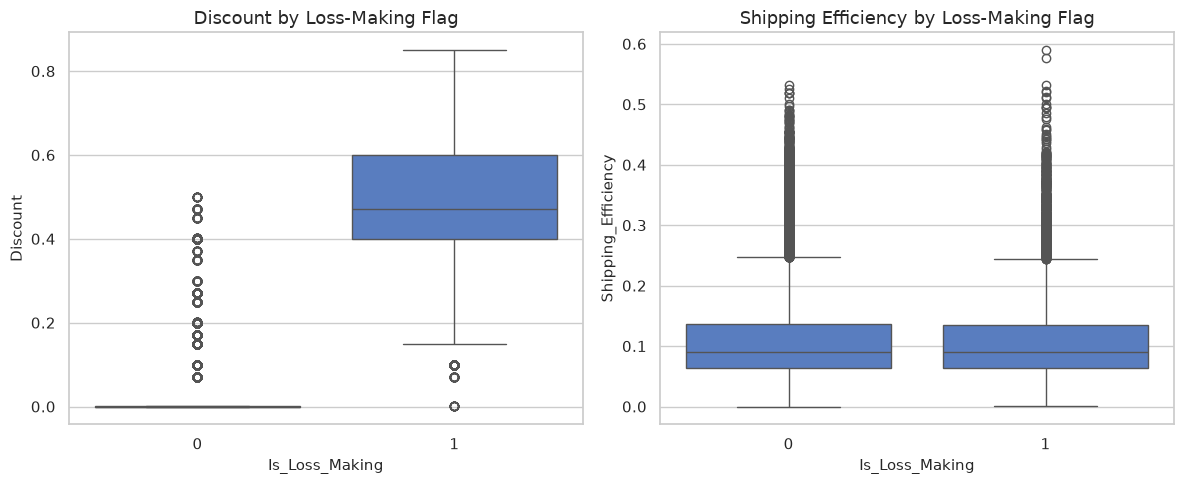

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x="Is_Loss_Making", y="Discount", ax=axes[0])
axes[0].set_title("Discount by Loss-Making Flag")
sns.boxplot(data=df, x="Is_Loss_Making", y="Shipping_Efficiency", ax=axes[1])
axes[1].set_title("Shipping Efficiency by Loss-Making Flag")
plt.tight_layout()
plt.show()


## 6. Feature Evaluation & Selection

**Goal:** Decide which features enter the Week 4 modelling dataset.  
Decisions use correlation, missingness, domain knowledge, and leakage risk — not correlation alone.


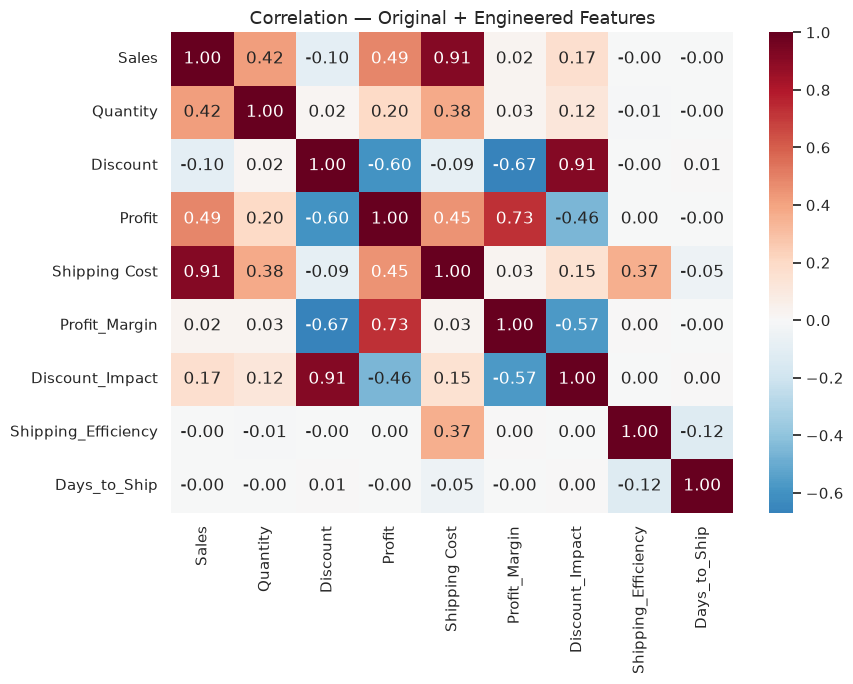

In [20]:
eval_cols = ["Sales", "Quantity", "Discount", "Profit", "Shipping Cost",
             "Profit_Margin", "Discount_Impact", "Shipping_Efficiency", "Days_to_Ship"]
corr2 = df[eval_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr2, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlation — Original + Engineered Features")
plt.tight_layout()
plt.show()


In [21]:
print("Mean values by Is_Loss_Making:")
display(df.groupby("Is_Loss_Making")[["Discount", "Discount_Impact", "Shipping_Efficiency", "Profit_Margin", "Sales"]].mean().round(3))


Mean values by Is_Loss_Making:


,Discount,Discount_Impact,Shipping_Efficiency,Profit_Margin,Sales
Is_Loss_Making,,,,,
0,0.043,12.079,0.109,0.250,262.027
1,0.451,70.020,0.109,-0.579,198.503


### Selection Decisions

| Feature | Decision | Justification |
|---------|----------|---------------|
| Row ID, Order ID, Customer Name, Product Name | **Remove** | Identifiers / high cardinality |
| Postal Code | **Remove** | ~80% missing |
| Sales, Quantity, Discount, Shipping Cost | **Keep** | Core drivers |
| Category, Sub-Category, Segment, Ship Mode, Order Priority, Market, Region | **Keep** | Business & statistical signal |
| Profit | **Keep as target** | Primary outcome |
| Profit_Margin, Is_Loss_Making | **Keep** | High value; **exclude from inputs** if they are the prediction target (leakage) |
| Discount_Impact, Shipping_Efficiency, Days_to_Ship | **Keep** | Engineered signal for modelling |

**Leakage rule:**  
- Predicting `Is_Loss_Making` → do **not** use `Profit` or `Profit_Margin` as inputs.  
- Predicting `Profit` → do **not** use `Profit_Margin` or `Is_Loss_Making` as inputs.


## 7. Dataset Refinement & Export

Produce the final modelling dataset for Week 4.


In [22]:
modelling_cols = [
    "Order Date", "Segment", "City", "State", "Country", "Market", "Region",
    "Category", "Sub-Category", "Sales", "Quantity", "Discount", "Profit",
    "Shipping Cost", "Ship Mode", "Order Priority",
    "Profit_Margin", "Is_Loss_Making", "Discount_Impact",
    "Shipping_Efficiency", "Days_to_Ship",
]

df_model = df[modelling_cols].copy()
print("Modelling dataset shape:", df_model.shape)
print("Columns:", df_model.columns.tolist())


Modelling dataset shape: (51290, 21)
Columns: ['Order Date', 'Segment', 'City', 'State', 'Country', 'Market', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Ship Mode', 'Order Priority', 'Profit_Margin', 'Is_Loss_Making', 'Discount_Impact', 'Shipping_Efficiency', 'Days_to_Ship']


In [23]:
import os
os.makedirs("../data/modelling", exist_ok=True)
out_path = "../data/modelling/global_superstore_modelling_dataset.csv"
df_model.to_csv(out_path, index=False)
print("Saved:", out_path)
print("Rows:", len(df_model), "| Columns:", len(df_model.columns))
df_model.head()


Saved: ../data/modelling/global_superstore_modelling_dataset.csv
Rows: 51290 | Columns: 21


,Order Date,Segment,City,State,Country,Market,Region,Category,Sub-Category,Sales,...,Discount,Profit,Shipping Cost,Ship Mode,Order Priority,Profit_Margin,Is_Loss_Making,Discount_Impact,Shipping_Efficiency,Days_to_Ship
0,2012-07-31,Consumer,New York City,New York,United States,US,East,Technology,Accessories,2309.650,...,0.0,762.1845,933.57,Same Day,Critical,0.330000,0,0.0000,0.404204,0
1,2013-05-02,Corporate,Wollongong,New South Wales,Australia,APAC,Oceania,Furniture,Chairs,3709.395,...,0.1,-288.7650,923.63,Second Class,Critical,-0.077847,1,370.9395,0.248997,61
2,2013-10-17,Consumer,Brisbane,Queensland,Australia,APAC,Oceania,Technology,Phones,5175.171,...,0.1,919.9710,915.49,First Class,Medium,0.177766,0,517.5171,0.176900,1
3,2013-01-28,Home Office,Berlin,Berlin,Germany,EU,Central,Technology,Phones,2892.510,...,0.1,-96.5400,910.16,First Class,Medium,-0.033376,1,289.2510,0.314661,2
4,2013-05-11,Consumer,Dakar,Dakar,Senegal,Africa,Africa,Technology,Copiers,2832.960,...,0.0,311.5200,903.04,Same Day,Critical,0.109963,0,0.0000,0.318762,31


## 8. Business Insights Summary

### Key validated findings
1. **Category matters** — profit differs significantly across Technology, Furniture, and Office Supplies.
2. **Discounting destroys value** — discounted orders are far less profitable (often loss-making).
3. **~24.5% of orders lose money** — systemic margin leakage, not isolated incidents.
4. **Furniture** has the highest loss rate; **Technology** has the strongest average profit.
5. Engineered features (`Profit_Margin`, `Is_Loss_Making`, `Discount_Impact`, `Shipping_Efficiency`) make risk and efficiency measurable.

### Priority recommendations
1. **Redesign discount policy** — cap discounts on weak-margin categories; monitor Discount_Impact weekly.
2. **Protect & grow Technology** — allocate growth focus where profit support is strongest.
3. **Furniture turnaround** — review pricing, cost, and discount rules; set a loss-rate reduction target.
4. **Operational efficiency** — use Shipping_Efficiency to compare Ship Modes and Markets.
5. **Prepare predictive control (Week 4)** — model `Is_Loss_Making` or `Profit` to flag high-risk orders before confirmation.

### Limitations
- Postal Code mostly missing outside the US
- Profit is given without full cost breakdown
- Observational data → association ≠ causation
- High-cardinality fields need careful encoding for modelling

### Next step (Week 4)
Use `global_superstore_modelling_dataset.csv` to build classification/regression models and translate predictive performance into final business recommendations.


---
**End of Week 3 Notebook**  
Analyst: Ozoeze Wilord Ugonna | AnalystLab Africa Data Science Internship
